# 🔍 Stage 1 — Baseline Anomaly Detector on MVTec AD

**Project:** Energy-Aware Visual Anomaly Detection on MCUs  
**Stage:** 1 / 4 — train an FP32 baseline that fits the MCU budget *before* any compression.

## What this notebook does

1. Sets up the environment (PyTorch + utilities).
2. Downloads MVTec AD (one or two categories) into Colab.
3. Defines a **compact convolutional autoencoder** sized to fit a Cortex-M4 (Arduino Nano 33 BLE Sense Rev 2 — 256 KB SRAM, 1 MB Flash).
4. Trains it on **defect-free images only** (unsupervised).
5. Evaluates on the MVTec test set: per-image AUROC, qualitative reconstructions, score histograms.
6. Reports parameter count, MAC count, and estimated INT8 model size to confirm we are in MCU-budget territory.
7. Saves the model in a format ready for Stage 2 (compression).

## Why an autoencoder and not PaDiM / PatchCore / EfficientAD?

PaDiM / PatchCore rely on a **pretrained ImageNet backbone** (Wide-ResNet, EfficientNet) and a large memory bank or covariance matrices — neither of which fits a 256 KB SRAM MCU after compression. They are great references for AUROC on a workstation, but they are not realistic Stage-1 baselines for our deployment target.

A small CNN autoencoder trained from scratch on defect-free images is:

- small enough to fit a Cortex-M4 after INT8 quantization;
- well-suited to all three of our Stage-2 compression techniques (PTQ, structured pruning, distillation);
- a fair representative of what gets deployed in published MCU-class anomaly detection work.

We may revisit a feature-based head later, but we will not get one to fit on the MCU without making it look like an autoencoder anyway.

## Why PyTorch, not TensorFlow

Stage 2 needs structured filter pruning with Taylor-importance ranking. PyTorch's tooling for this is more mature than TFMOT's. The TFLite export path used by Stage 3 starts from PyTorch via ONNX. We accept the conversion cost (one script) in exchange for a smoother compression workflow.

---

## 0. Environment setup

Colab already provides PyTorch and CUDA. We install only the few extras we actually need.

- `scikit-learn` — for AUROC.
- `ptflops` — measures MACs / parameters of a PyTorch model.
- `tqdm`, `matplotlib`, `Pillow` — UI + plotting.

In [1]:
!pip install -q ptflops scikit-learn tqdm matplotlib pillow

In [2]:
import os, random, math, time, json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from ptflops import get_model_complexity_info
from tqdm.auto import tqdm

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

Torch: 2.10.0+cu128 | Device: cuda


## 1. Configuration

All parameters in one place.

Defaults are tuned for: 
- one MVTec category
- small input resolution
  (original image 1024x1024 -> resize to 128x128 -> so the AE fits the MCU)
- short training run that is enough to validate the pipeline. 

We will sweep categories and epochs later. ????

CFG -> Python dictionary to store experiment settings

In [3]:
CFG = {
    # data
    'category': 'bottle',          # start with one category; loop later
    'image_size': 128,             # 128x128 — small enough to fit MCU SRAM after INT8
    'data_root': '/content/mvtec',

    # training
    'batch_size': 32,
    'epochs': 60,
    'lr': 1e-3,
    'weight_decay': 1e-5,
    'num_workers': 2,

    # model
    'base_channels': 16,           # capacity parameter
    'latent_channels': 32,         # bottleneck depth

    # eval - Mean pooling to get single anomaly score for the whole image
    'score_pool': 'mean',          # 'mean' | 'max' over per-pixel reconstruction error

    # output
    'out_dir': '/content/baseline_out',
}
Path(CFG['out_dir']).mkdir(parents=True, exist_ok=True)
print(json.dumps(CFG, indent=2))

{
  "category": "bottle",
  "image_size": 128,
  "data_root": "/content/mvtec",
  "batch_size": 32,
  "epochs": 60,
  "lr": 0.001,
  "weight_decay": 1e-05,
  "num_workers": 2,
  "base_channels": 16,
  "latent_channels": 32,
  "score_pool": "mean",
  "out_dir": "/content/baseline_out"
}


## 2. Get the data

MVTec AD is distributed by MVTec Software GmbH under a non-commercial research license. 
The full dataset is ~4.9 GB. 
For Stage 1 we only need one category, bottle.

```
/content/mvtec/bottle/
├── train/good/                  # only defect-free images
├── test/
│   ├── good/                    # defect-free test
│   ├── broken_large/
│   ├── broken_small/
│   └── contamination/
└── ground_truth/                # pixel masks (unused at Stage 1)
```

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
from pathlib import Path

DATA_ROOT = Path('/content/mvtec')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# point /content/mvtec/bottle → /content/drive/MyDrive/MVTec/bottle
src = '/content/drive/MyDrive/mvtec/bottle'
dst = '/content/mvtec/bottle'
if not os.path.exists(dst):
    os.symlink(src, dst)

!ls -la /content/drive/MyDrive/
!ls -la /content/drive/MyDrive/mvtec/ 2>/dev/null || echo "MVTec folder not found"

!ls /content/drive/MyDrive/ | grep -i mvtec

# sanity check
!ls /content/drive/MyDrive/mvtec/bottle
!ls /content/mvtec/bottle/

total 110
drwx------ 2 root root  4096 Mar 10 07:28 'Colab Notebooks'
-rw------- 1 root root   192 May 14 12:07  conversational_clustering_proposal.gslides
drwx------ 2 root root  4096 Apr 20 06:48  datasets
-rw------- 1 root root   192 May 11 12:57 'Documento senza titolo.gdoc'
-rw------- 1 root root   192 Apr 13 08:35  Full_Script.gdoc
-rw------- 1 root root 95840 Apr 13 13:15  Italian_Work_Songs_V1.pptx
-rw------- 1 root root   192 Apr  9 09:47 'Monumento a Dante Alighieri.gdoc'
drwx------ 3 root root  4096 May 21 08:41  mvtec
-rw------- 1 root root   192 Apr 10 16:42  Presenter_Guide.gdoc
-rw------- 1 root root   192 May 11 12:37  Project_Proposal_Energy_Aware_Visual_Anomaly_Detection.gdoc
-rw------- 1 root root   192 Apr 10 14:49 'Summary of Research for Both Songs.gdoc'
total 4
drwx------ 5 root root 4096 May 21 08:41 bottle
mvtec
ground_truth  license.txt  readme.txt  test  train


In [14]:
import os, shutil
from pathlib import Path

src = '/content/drive/MyDrive/mvtec/bottle'
dst = '/content/mvtec/bottle'

Path('/content/mvtec').mkdir(parents=True, exist_ok=True)

# nuke whatever is at dst, regardless of what it is
if os.path.islink(dst):
    os.unlink(dst)
elif os.path.isdir(dst):
    shutil.rmtree(dst)
elif os.path.exists(dst):
    os.remove(dst)

assert os.path.isdir(src), f'Source not found: {src}'
os.symlink(src, dst)

# verify
print('symlink:', os.path.islink(dst))
print('contents:', os.listdir(dst)[:10])

symlink: True
contents: ['readme.txt', 'license.txt', 'test', 'train', 'ground_truth']


In [4]:
# Download a single MVTec category. URLs may change — fall back to manual upload if needed.
import urllib.request, tarfile, shutil

CATEGORY = CFG['category']
DATA_ROOT = Path(CFG['data_root'])
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# MVTec hosts per-category tarballs at predictable URLs (subject to change).
URL = f'https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938113-1629952094/{CATEGORY}.tar.xz'
tar_path = DATA_ROOT / f'{CATEGORY}.tar.xz'
cat_dir = DATA_ROOT / CATEGORY

if not cat_dir.exists():
    if not tar_path.exists():
        print(f'Downloading {URL} ...')
        try:
            urllib.request.urlretrieve(URL, tar_path)
        except Exception as e:
            print('Automatic download failed:', e)
            print('Please download MVTec AD manually and upload', CATEGORY, 'to', DATA_ROOT)
    if tar_path.exists():
        print('Extracting ...')
        with tarfile.open(tar_path) as t:
            t.extractall(DATA_ROOT)
        tar_path.unlink()
else:
    print(f'{cat_dir} already present.')

# Sanity-check folder layout
for sub in ['train/good', 'test']:
    p = cat_dir / sub
    assert p.exists(), f'Missing: {p}. Upload the category manually.'
    print(p, '→', sum(1 for _ in p.rglob('*.png')), 'png files')

Automatic download failed: HTTP Error 404: Not Found
Please download MVTec AD manually and upload bottle to /content/mvtec


AssertionError: Missing: /content/mvtec/bottle/train/good. Upload the category manually.

## 3. Dataset and dataloaders

Training set: `train/good` only — unsupervised AE training on defect-free images.

Test set: all subfolders of `test/`, with binary label `0` for `good` and `1` otherwise.

Preprocessing: resize to `image_size`, center-crop, convert to tensor in `[0, 1]`. We **do not** apply ImageNet normalization because we are not using a pretrained backbone and we want to keep the deployed model's input pipeline trivially reproducible on the MCU.

Light augmentation on the train set (small rotation, horizontal flip) helps generalize without changing the defect-free assumption.

In [15]:
class MVTecTrain(Dataset):
    """Defect-free training images for unsupervised AE."""
    def __init__(self, root, image_size):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        assert self.paths, f'No train images under {root}/train/good'
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(5),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.tf(img)

class MVTecTest(Dataset):
    """Test set with binary labels (0 = good, 1 = any defect)."""
    def __init__(self, root, image_size):
        test_root = Path(root, 'test')
        self.items = []
        for sub in sorted(test_root.iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')):
                self.items.append((p, label, sub.name))
        assert self.items, f'No test images under {test_root}'
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, label, defect = self.items[i]
        img = Image.open(p).convert('RGB')
        return self.tf(img), label, defect

train_ds = MVTecTrain(cat_dir, CFG['image_size'])
test_ds  = MVTecTest(cat_dir, CFG['image_size'])
print(f'train: {len(train_ds)} | test: {len(test_ds)} (good={sum(1 for _,l,_ in test_ds.items if l==0)}, defect={sum(1 for _,l,_ in test_ds.items if l==1)})')

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

train: 209 | test: 83 (good=20, defect=63)


### Visualize a few training images

Defect-free training images

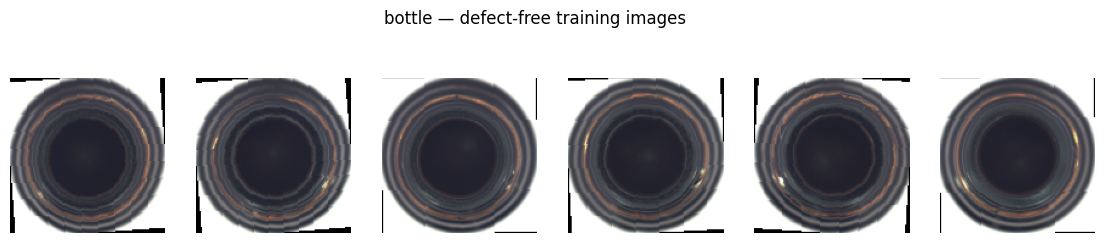

In [16]:
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, i in zip(axes, np.random.choice(len(train_ds), 6, replace=False)):
    img = train_ds[i].permute(1,2,0).numpy()
    ax.imshow(img); ax.axis('off')
plt.suptitle(f'{CFG["category"]} — defect-free training images'); plt.show()

## 4. Model: compact convolutional autoencoder

Architecture summary (128×128 input):

```
Encoder:  3 → C → 2C → 4C → latent          (4 downsamplings, factor 16)
Decoder:  latent → 4C → 2C → C → 3          (mirror, transpose convs)
```

With `C = base_channels = 16` and `latent = 32`, the model lands in the ~80–120 k parameter range — fits a 1 MB Flash budget comfortably after INT8 quantization (≈1 byte/param), and leaves headroom for activations in 256 KB SRAM.

Design choices that matter for Stage 2 / Stage 3:

- **No batch norm** (or only minimal): batch-norm folding works in TFLite but adds friction; using only conv + ReLU keeps quantization clean.
- **ReLU**, not GELU / SiLU: simple activations are quantization-friendly and supported in TFLite Micro.
- **No skip connections** in the baseline. They would hurt reconstruction-error-based anomaly scoring (the model copies the defect through the skip) and complicate pruning. We can revisit.
- **Transpose convs**, not upsample+conv. Either works; transpose convs are supported by TFLM and keep the parameter count visible.

In [17]:
def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=4, stride=stride, padding=1, bias=True),
        nn.ReLU(inplace=True),
    )

def deconv_block(in_c, out_c):
    return nn.Sequential(
        nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1, bias=True),
        nn.ReLU(inplace=True),
    )

class CompactAE(nn.Module):
    def __init__(self, base=16, latent=32):
        super().__init__()
        c1, c2, c3 = base, base*2, base*4
        self.enc = nn.Sequential(
            conv_block(3,  c1),                  # 128 -> 64
            conv_block(c1, c2),                  # 64  -> 32
            conv_block(c2, c3),                  # 32  -> 16
            conv_block(c3, latent),              # 16  -> 8
        )
        self.dec = nn.Sequential(
            deconv_block(latent, c3),            # 8  -> 16
            deconv_block(c3, c2),                # 16 -> 32
            deconv_block(c2, c1),                # 32 -> 64
            nn.ConvTranspose2d(c1, 3, 4, 2, 1),  # 64 -> 128, linear output
            nn.Sigmoid(),                        # constrain output to [0,1]
        )
    def forward(self, x):
        return self.dec(self.enc(x))

model = CompactAE(base=CFG['base_channels'], latent=CFG['latent_channels']).to(DEVICE)
print(model)

CompactAE(
  (enc): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (dec): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU

### Budget check **before** we train

If the model already blows the MCU budget at FP32, no amount of compression will save it. 

In [18]:
with torch.cuda.device(0 if DEVICE=='cuda' else -1):
    macs, params = get_model_complexity_info(
        model, (3, CFG['image_size'], CFG['image_size']),
        as_strings=False, print_per_layer_stat=False, verbose=False,
    )

n_params = sum(p.numel() for p in model.parameters())
fp32_kb  = n_params * 4 / 1024
int8_kb  = n_params * 1 / 1024     # approximate (excludes per-tensor scales)

print(f'Parameters : {n_params:,}')
print(f'MACs       : {macs/1e6:.2f} M')
print(f'Size FP32  : {fp32_kb:.1f} KB')
print(f'Size INT8  : {int8_kb:.1f} KB   (target Flash budget: 1024 KB)')

assert int8_kb < 800, 'Model too big for MCU budget after INT8. Shrink base_channels / latent.'

Parameters : 149,251
MACs       : 44.78 M
Size FP32  : 583.0 KB
Size INT8  : 145.8 KB   (target Flash budget: 1024 KB)


## 5. Training

Loss: pixel-wise **L2** between input and reconstruction. Plain MSE is robust and quantization-friendly; SSIM-based losses are common in the AD literature but harder to deploy on the MCU and not necessary for the baseline.

Optimizer: Adam with `lr=1e-3`, cosine schedule. No early stopping — we let it run the full budget so the loss curve is informative for Stage 2 ablations.

We track the *reconstruction loss on training data* (no validation set on defect-free data — the test set lives in `test/`).

epoch 1/60:   0%|          | 0/6 [00:00<?, ?it/s]

epoch   1 | train_loss = 0.10152 | lr = 0.00100


epoch 2/60:   0%|          | 0/6 [00:00<?, ?it/s]

epoch   2 | train_loss = 0.10015 | lr = 0.00100


epoch 3/60:   0%|          | 0/6 [00:00<?, ?it/s]

...

epoch  58 | train_loss = 0.01806 | lr = 0.00000


epoch 59/60:   0%|          | 0/6 [00:00<?, ?it/s]

epoch  59 | train_loss = 0.01728 | lr = 0.00000


epoch 60/60:   0%|          | 0/6 [00:00<?, ?it/s]

epoch  60 | train_loss = 0.01751 | lr = 0.00000


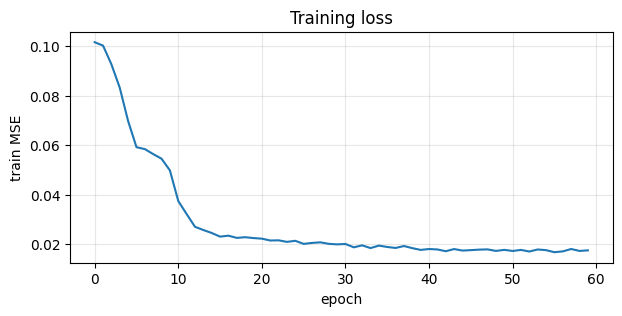

In [19]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

history = []
for epoch in range(CFG['epochs']):
    model.train()
    total_loss, n = 0.0, 0
    for x in tqdm(train_loader, desc=f'epoch {epoch+1}/{CFG["epochs"]}', leave=False):
        x = x.to(DEVICE, non_blocking=True)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * x.size(0); n += x.size(0)
    scheduler.step()
    epoch_loss = total_loss / n
    history.append(epoch_loss)
    print(f'epoch {epoch+1:3d} | train_loss = {epoch_loss:.5f} | lr = {scheduler.get_last_lr()[0]:.5f}')

plt.figure(figsize=(7,3))
plt.plot(history); plt.xlabel('epoch'); plt.ylabel('train MSE'); plt.title('Training loss'); plt.grid(alpha=.3); plt.show()

## 6. Evaluation

### Anomaly score

For each test image we compute the per-pixel reconstruction error map `(x - x_hat)^2`, averaged over channels. The image-level anomaly score is the **spatial mean** of that map (alternative: `max` — set in `CFG['score_pool']`).

Reporting:

- **image-level AUROC** — the standard MVTec metric, comparing scores to binary labels.
- a histogram of scores split by `good` vs defect.
- a small grid of reconstructions and error maps.

AUROC is preferred over accuracy because the threshold is application-specific.

In [20]:
@torch.no_grad()
def score_images(model, loader):
    model.eval()
    scores, labels, defects = [], [], []
    for x, y, d in loader:
        x = x.to(DEVICE)
        x_hat = model(x)
        err = (x - x_hat).pow(2).mean(dim=1)              # B x H x W
        if CFG['score_pool'] == 'max':
            s = err.amax(dim=(1,2))
        else:
            s = err.mean(dim=(1,2))
        scores.append(s.cpu().numpy()); labels.append(y.numpy()); defects.extend(d)
    return np.concatenate(scores), np.concatenate(labels), defects

scores, labels, defects = score_images(model, test_loader)
auroc = roc_auc_score(labels, scores)
print(f'image-level AUROC on {CFG["category"]}: {auroc:.4f}')

image-level AUROC on bottle: 0.6770


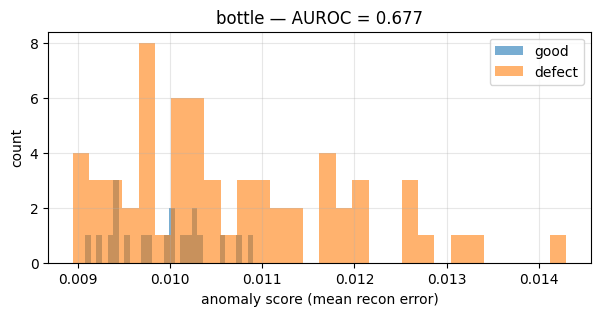

In [21]:
# Score distributions
plt.figure(figsize=(7,3))
plt.hist(scores[labels==0], bins=30, alpha=.6, label='good')
plt.hist(scores[labels==1], bins=30, alpha=.6, label='defect')
plt.xlabel('anomaly score (mean recon error)'); plt.ylabel('count')
plt.title(f'{CFG["category"]} — AUROC = {auroc:.3f}'); plt.legend(); plt.grid(alpha=.3); plt.show()

In [22]:
# Per-defect-type breakdown
from collections import defaultdict
by_defect = defaultdict(list)
for s, d in zip(scores, defects):
    by_defect[d].append(s)
for d, arr in by_defect.items():
    arr = np.array(arr)
    print(f'  {d:20s} n={len(arr):3d}  mean={arr.mean():.4f}  median={np.median(arr):.4f}')

  broken_large         n= 20  mean=0.0106  median=0.0104
  broken_small         n= 22  mean=0.0105  median=0.0102
  contamination        n= 21  mean=0.0108  median=0.0103
  good                 n= 20  mean=0.0099  median=0.0100


Defect examples:


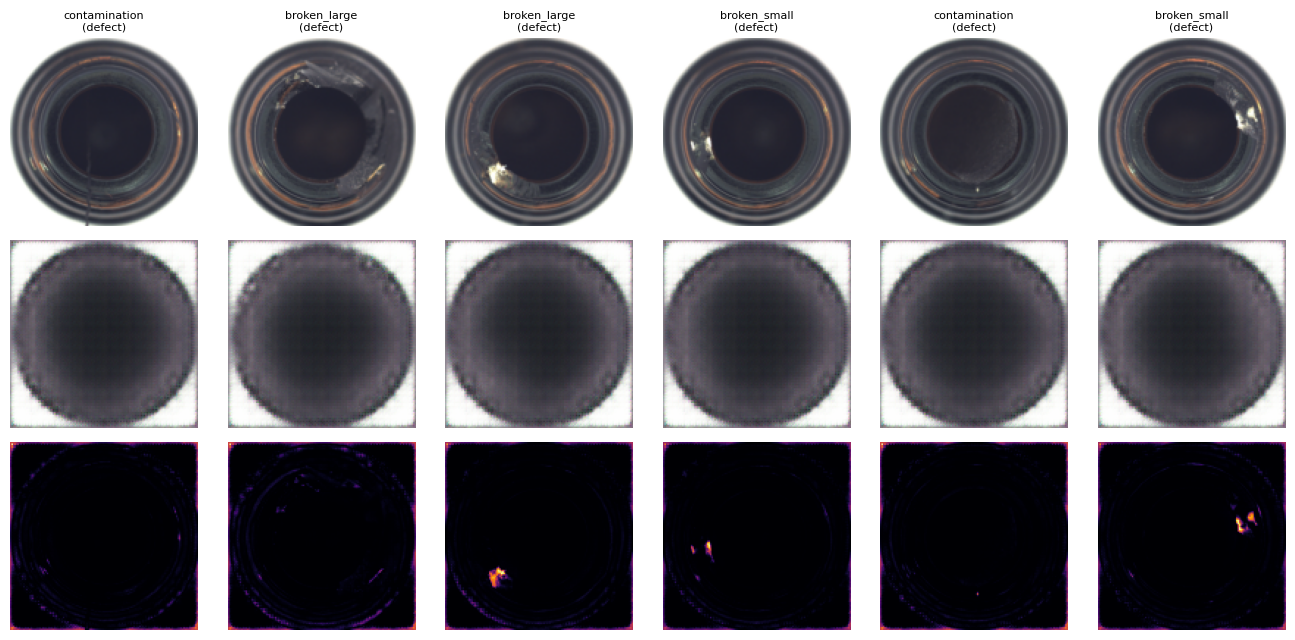

Good examples:


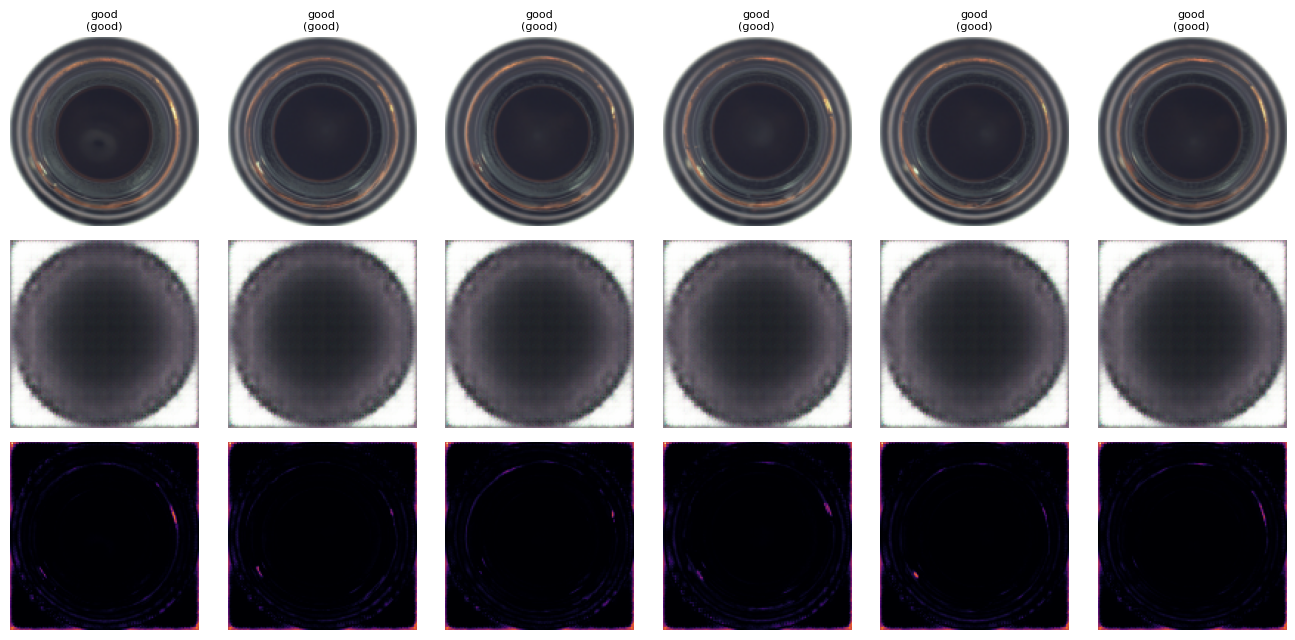

In [23]:
# Qualitative: reconstructions + error maps
@torch.no_grad()
def show_examples(model, ds, n=6, want_label=None):
    model.eval()
    idxs = [i for i,(p,l,d) in enumerate(ds.items) if (want_label is None or l==want_label)]
    idxs = np.random.choice(idxs, n, replace=False)
    fig, axes = plt.subplots(3, n, figsize=(2.2*n, 6.5))
    for col, i in enumerate(idxs):
        x, l, d = ds[i]
        xt = x.unsqueeze(0).to(DEVICE)
        xh = model(xt).squeeze(0).cpu()
        err = (x - xh).pow(2).mean(0)
        axes[0,col].imshow(x.permute(1,2,0)); axes[0,col].set_title(f'{d}\n({"good" if l==0 else "defect"})', fontsize=8); axes[0,col].axis('off')
        axes[1,col].imshow(xh.permute(1,2,0).clamp(0,1)); axes[1,col].axis('off')
        axes[2,col].imshow(err, cmap='inferno'); axes[2,col].axis('off')
    axes[0,0].set_ylabel('input',  rotation=0, ha='right');
    axes[1,0].set_ylabel('recon',  rotation=0, ha='right')
    axes[2,0].set_ylabel('error',  rotation=0, ha='right')
    plt.tight_layout(); plt.show()

print('Defect examples:'); show_examples(model, test_ds, n=6, want_label=1)
print('Good examples:');   show_examples(model, test_ds, n=6, want_label=0)

## 7. Save artifacts for Stage 2

Stage 2 (compression) starts from:

- the **state dict** (for pruning, distillation, quantization-aware fine-tuning),
- the **config** (so the architecture can be rebuilt deterministically),
- the **baseline metrics** (so every compressed variant is compared against the same reference).

We dump everything to `CFG['out_dir']`.

In [ ]:
ckpt_path = Path(CFG['out_dir']) / f'baseline_{CFG["category"]}.pt'
torch.save({
    'state_dict': model.state_dict(),
    'config': CFG,
    'metrics': {
        'auroc': float(auroc),
        'n_params': n_params,
        'macs': int(macs),
        'fp32_kb': float(fp32_kb),
        'int8_kb_est': float(int8_kb),
    },
    'final_train_loss': float(history[-1]),
}, ckpt_path)
print('Saved:', ckpt_path)

summary_path = Path(CFG['out_dir']) / f'baseline_{CFG["category"]}_summary.json'
summary = {
    'category': CFG['category'],
    'image_size': CFG['image_size'],
    'auroc': float(auroc),
    'n_params': n_params,
    'macs_M': macs/1e6,
    'fp32_kb': fp32_kb,
    'int8_kb_est': int8_kb,
    'epochs': CFG['epochs'],
    'final_train_loss': history[-1],
}
summary_path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

In [ ]:
# Optional: download the checkpoint to your laptop / push to Drive
from google.colab import files
files.download(str(ckpt_path))
files.download(str(summary_path))

## 8. What to expect and what to do next

### Expected AUROC for the baseline

A small AE on `bottle` at 128×128 trained for 60 epochs typically lands in the **0.85–0.95 AUROC** range. This is below PaDiM (~0.99) and EfficientAD (~0.998), which is expected: those methods use heavy pretrained backbones. What matters for our project is that the baseline is **above 0.85** so there is enough headroom to study how compression degrades it.

If AUROC is below 0.80:

- train longer (`epochs = 120`),
- bump capacity (`base_channels = 24`, `latent_channels = 48`),
- try `score_pool = 'max'` — for small defects, max pooling of the error map is often better than mean.

If AUROC is already above 0.95: leave it alone, ship the baseline.

### Looping over categories

When the pipeline is validated on `bottle`, wrap sections 2–7 in a loop over `['bottle', 'hazelnut', 'metal_nut']` (or a wider list). Save one checkpoint per category. Stage 2 then iterates over all of them.

### Stage 2 starting point

The next notebook (`Stage2_Compression.ipynb`) will:

1. Load `baseline_<cat>.pt`.
2. Apply post-training INT8 quantization, structured pruning (L1 + Taylor) with short fine-tuning, and knowledge distillation into a smaller student.
3. Evaluate each variant on the same MVTec test split.
4. Produce the first Pareto plot (AUROC vs model size / MACs).

Do not touch the test set between stages — keep the comparison clean.